# LVIS Lidar Mission Planning

This notebook demonstrates how to plan missions for the **LVIS (Land, Vegetation,
and Ice Sensor)** full-waveform scanning lidar using HyPlan.

We cover:

1. LVIS sensor fundamentals (scanner geometry, laser footprint)
2. Lens options and their effect on coverage
3. Contiguous vs. non-contiguous coverage
4. Along-track sampling constraints
5. **Point density** (the primary planning metric)
6. **Survey solvers** (science requirements to flight constraints)
7. Swath polygon generation for flight planning
8. Altitude and speed trade-offs
9. **Terrain-aware footprint analysis**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from hyplan.instruments import (
    LVIS, LVISLens,
    LVIS_LENS_NARROW, LVIS_LENS_MEDIUM, LVIS_LENS_WIDE, LVIS_LENSES,
)
from hyplan.aircraft import NASA_P3, NASA_B777
from hyplan.flight_line import FlightLine
from hyplan.swath import generate_swath_polygon, calculate_swath_widths
from hyplan.units import ureg


## 1. LVIS Sensor Overview

LVIS is a full-waveform scanning lidar operated by NASA Goddard Space Flight Center.
The scanner has a fixed maximum swath of 0.2 x altitude (half-scan angle ~ 5.7 deg).
Whether that swath is filled contiguously depends on:

- **Laser repetition rate** (default 4000 Hz)
- **Lens divergence** (determines footprint diameter)
- **Aircraft ground speed**

In [2]:
lvis = LVIS()  # Default: 4000 Hz rep rate, wide lens

print(f"LVIS Default Configuration:")
print(f"  Rep rate:       {lvis.rep_rate}")
print(f"  Lens:           {lvis.lens.name} ({lvis.lens.divergence_mrad:.3f} mrad)")
print(f"  Half-scan angle: {lvis.half_angle:.2f} deg")

LVIS Default Configuration:
  Rep rate:       4000 hertz
  Lens:           wide (1.272 mrad)
  Half-scan angle: 5.71 deg


## 2. Lens Comparison

LVIS has three standard lens options. A wider divergence lens produces a
larger footprint, which helps fill the swath at higher speeds or altitudes.

In [3]:
rows = []
for name, lens in LVIS_LENSES.items():
    rows.append({
        "Lens": name,
        "Divergence (mrad)": lens.divergence_mrad,
    })

lens_df = pd.DataFrame(rows)
lens_df

,Lens,Divergence (mrad)
0,narrow,0.531
1,medium,0.790
2,wide,1.272


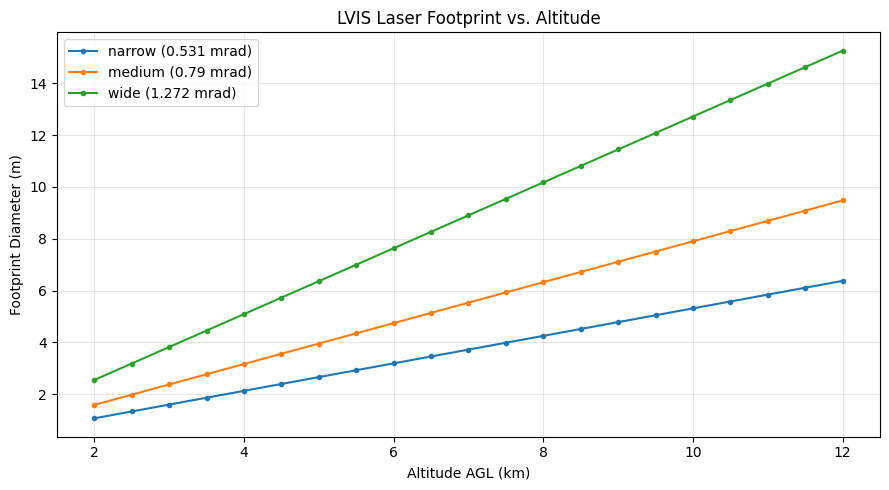

In [4]:
# Footprint diameter vs altitude for each lens
altitudes_m = np.arange(2000, 12001, 500)

fig, ax = plt.subplots(figsize=(9, 5))

for name, lens in LVIS_LENSES.items():
    footprints = [
        lens.footprint_diameter(ureg.Quantity(a, "meter")).magnitude
        for a in altitudes_m
    ]
    ax.plot(altitudes_m / 1000, footprints, "o-", markersize=3, label=f"{name} ({lens.divergence_mrad} mrad)")

ax.set_xlabel("Altitude AGL (km)")
ax.set_ylabel("Footprint Diameter (m)")
ax.set_title("LVIS Laser Footprint vs. Altitude")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Maximum vs. Effective Swath Width

The **maximum swath** is set by scanner geometry (0.2 x altitude). The
**effective swath** may be narrower if the laser footprint is too small
to tile the full swath at a given speed.

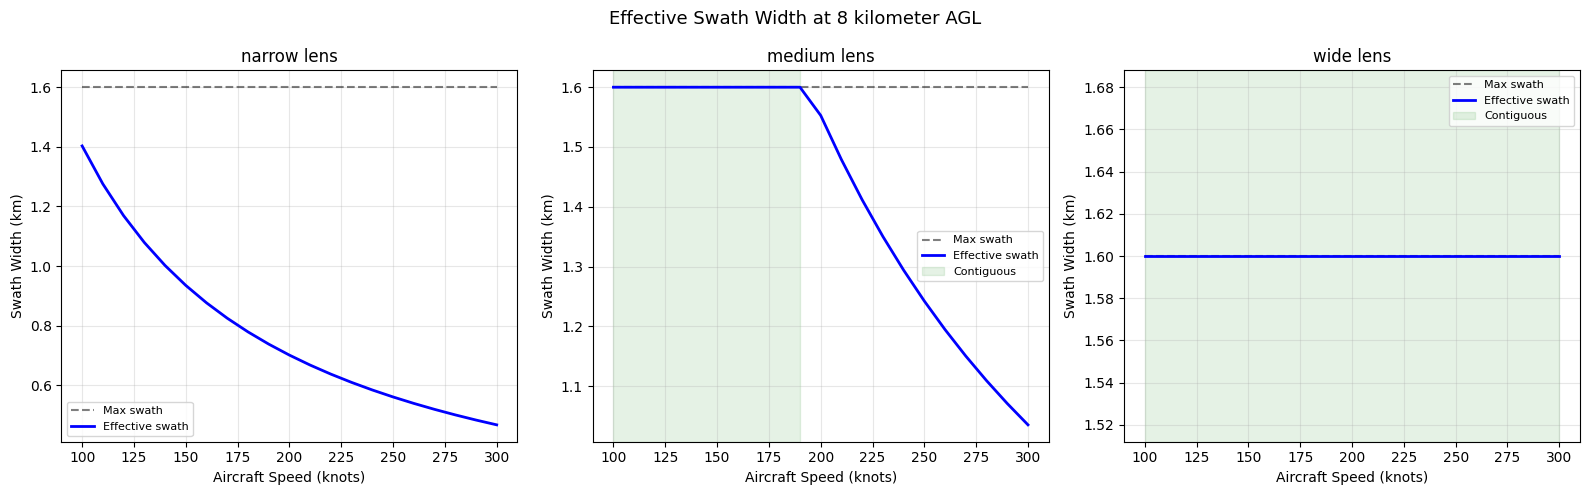

In [5]:
altitude = ureg.Quantity(8000, "meter")
speeds_kt = np.arange(100, 301, 10)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for name, lens in LVIS_LENSES.items():
    lvis_cfg = LVIS(lens=name)
    max_swaths = []
    eff_swaths = []
    contiguous_flags = []

    for spd in speeds_kt:
        speed = ureg.Quantity(spd, "knot")
        ms = lvis_cfg.swath_width(altitude).to(ureg.meter).magnitude
        es = lvis_cfg.effective_swath_width(altitude, speed).to(ureg.meter).magnitude
        max_swaths.append(ms)
        eff_swaths.append(es)
        contiguous_flags.append(lvis_cfg.is_contiguous(altitude, speed))

    ax = axes[list(LVIS_LENSES.keys()).index(name)]
    ax.plot(speeds_kt, np.array(max_swaths) / 1000, "k--", alpha=0.5, label="Max swath")
    ax.plot(speeds_kt, np.array(eff_swaths) / 1000, "b-", linewidth=2, label="Effective swath")

    # Shade contiguous region
    cont_speeds = [s for s, c in zip(speeds_kt, contiguous_flags) if c]
    if cont_speeds:
        ax.axvspan(speeds_kt[0], max(cont_speeds), alpha=0.1, color="green", label="Contiguous")

    ax.set_xlabel("Aircraft Speed (knots)")
    ax.set_ylabel("Swath Width (km)")
    ax.set_title(f"{name} lens")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Effective Swath Width at {altitude.to(ureg.km):.0f} AGL", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Coverage Summary

The `summary()` and `print_summary()` methods provide a complete
set of coverage parameters for a given flight configuration.

In [6]:
altitude = ureg.Quantity(8000, "meter")
speed = ureg.Quantity(200, "knot")

lvis_wide = LVIS(lens="wide")
lvis_wide.print_summary(altitude, speed)

LVIS Coverage Summary
  Altitude AGL:          8000 meter
  Speed:                 200 knot
  Rep rate:              4000 hertz
  Lens:                  wide (1.272 mrad)
  Footprint diameter:    10.2 meter
  Max swath (geometric): 1600 meter
  Effective swath width: 1600.0 meter
  Cross-track contiguous:True
  Along-track spacing:   0.03 meter
  Along-track contiguous:True
  Point density:         0.0243 / meter ** 2
  Coverage rate:         164622 meter ** 2 / second
  Footprint to fill max: 6.4 meter


In [7]:
# Compare all lenses at once
lvis_wide.compare_lenses(altitude, speed)

LVIS Lens Comparison at 8.0 kilometer AGL, 200 knot
  Rep rate: 4000 hertz   Max swath: 1600 m
  Lens          Diverg   Footprint   Eff Swath       Density  Contiguous
  ----------  --------  ----------  ----------  ------------  ----------
  narrow        0.531         4.2 m      701.6 m      0.0554/m^2          no
  medium        0.790         6.3 m     1552.8 m      0.0250/m^2          no
  wide          1.272        10.2 m     1600.0 m      0.0243/m^2         yes


## 5. Along-Track Sampling

LVIS coverage has **two independent constraints**: cross-track (swath tiling) and
along-track (shot spacing). The along-track spacing is simply `speed / rep_rate` —
if this exceeds the footprint diameter, there are gaps between consecutive shots
along the flight direction.

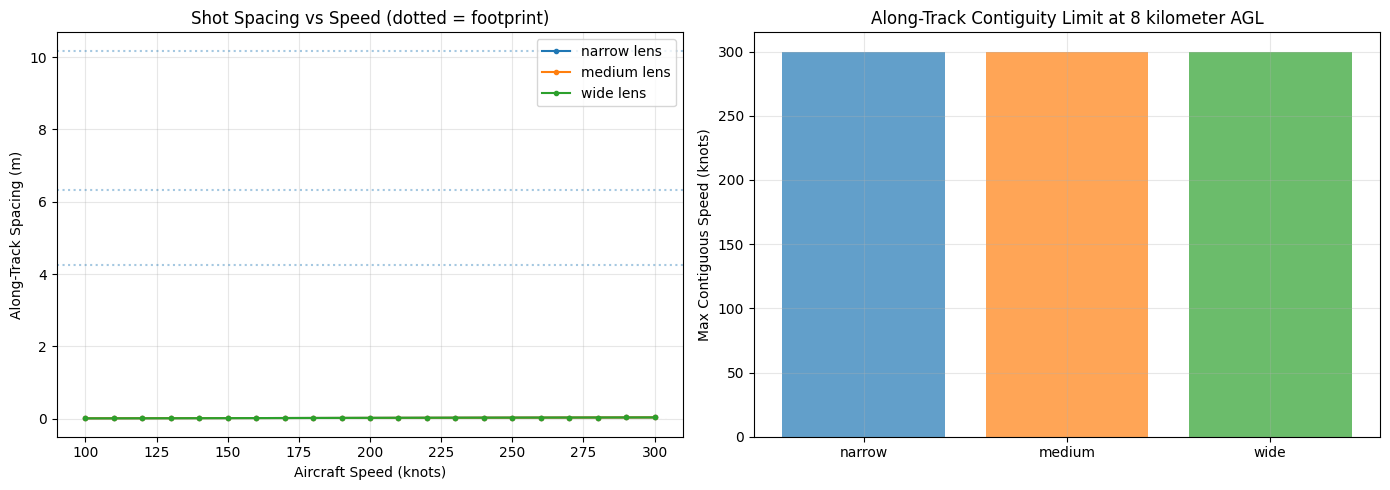

In [8]:
altitude = ureg.Quantity(8000, "meter")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in LVIS_LENSES:
    lvis_cfg = LVIS(lens=name)
    spacings = [lvis_cfg.along_track_spacing(ureg.Quantity(s, "knot")).magnitude for s in speeds_kt]
    footprint = lvis_cfg.footprint_diameter(altitude).magnitude
    contiguous = [lvis_cfg.is_along_track_contiguous(altitude, ureg.Quantity(s, "knot")) for s in speeds_kt]

    axes[0].plot(speeds_kt, spacings, "o-", markersize=3, label=f"{name} lens")
    axes[0].axhline(y=footprint, linestyle=":", alpha=0.4)

    # Max speed for along-track contiguity
    max_speed = [s for s, c in zip(speeds_kt, contiguous) if c]
    if max_speed:
        axes[1].bar(name, max(max_speed), alpha=0.7)

axes[0].set_xlabel("Aircraft Speed (knots)")
axes[0].set_ylabel("Along-Track Spacing (m)")
axes[0].set_title("Shot Spacing vs Speed (dotted = footprint)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel("Max Contiguous Speed (knots)")
axes[1].set_title(f"Along-Track Contiguity Limit at {altitude.to(ureg.km):.0f} AGL")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Point Density

Point density (`shots/m²`) is the **primary planning metric** for LVIS surveys.
It determines whether the science requirements for canopy height, biomass estimation,
or bathymetry can be met.

`point_density = rep_rate / (speed * effective_swath)`

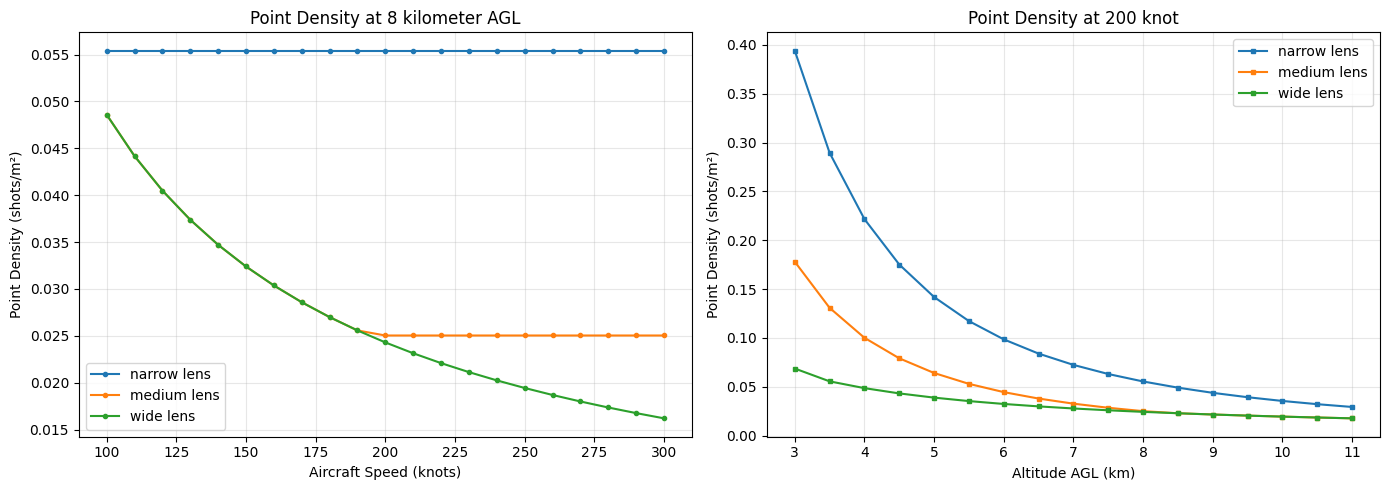

In [9]:
altitude = ureg.Quantity(8000, "meter")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Point density vs speed for each lens
for name in LVIS_LENSES:
    lvis_cfg = LVIS(lens=name)
    densities = [
        lvis_cfg.point_density(altitude, ureg.Quantity(s, "knot")).magnitude
        for s in speeds_kt
    ]
    axes[0].plot(speeds_kt, densities, "o-", markersize=3, label=f"{name} lens")

axes[0].set_xlabel("Aircraft Speed (knots)")
axes[0].set_ylabel("Point Density (shots/m²)")
axes[0].set_title(f"Point Density at {altitude.to(ureg.km):.0f} AGL")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Point density vs altitude at fixed speed
speed = ureg.Quantity(200, "knot")
alts_m = np.arange(3000, 11001, 500)

for name in LVIS_LENSES:
    lvis_cfg = LVIS(lens=name)
    densities = [
        lvis_cfg.point_density(ureg.Quantity(a, "meter"), speed).magnitude
        for a in alts_m
    ]
    axes[1].plot(alts_m / 1000, densities, "s-", markersize=3, label=f"{name} lens")

axes[1].set_xlabel("Altitude AGL (km)")
axes[1].set_ylabel("Point Density (shots/m²)")
axes[1].set_title(f"Point Density at {speed}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Survey Solvers: From Science Requirements to Flight Constraints

Instead of iterating manually, the survey solvers **invert the forward model**
to answer:

- `solve_for_speed(target_density, altitude)` — *"What's the fastest I can fly?"*
- `solve_for_altitude(target_density, speed)` — *"What's the highest I can fly?"*

This turns LVIS into a **decision support system**.

In [10]:
# Example: biomass survey requires >= 0.005 shots/m²
target = 0.005 / ureg.meter ** 2
lvis_w = LVIS(lens="wide")

print("Survey Solver Results")
print(f"  Target density: {target:.4f}")
print()

# What speed can I fly at different altitudes?
for alt_km in [5, 8, 10]:
    alt = ureg.Quantity(alt_km * 1000, "meter")
    max_speed = lvis_w.solve_for_speed(target, alt)
    actual_density = lvis_w.point_density(alt, max_speed)
    print(f"  At {alt_km} km AGL:")
    print(f"    Max speed: {max_speed.to(ureg.knot):.0f}")
    print(f"    Achieved density: {actual_density:.4f}")
    print()

# What altitude can I fly at different speeds?
for spd_kt in [150, 200, 250]:
    spd = ureg.Quantity(spd_kt, "knot")
    max_alt = lvis_w.solve_for_altitude(target, spd)
    actual_density = lvis_w.point_density(max_alt, spd)
    print(f"  At {spd_kt} kt:")
    print(f"    Max altitude: {max_alt.to(ureg.km):.2f}")
    print(f"    Achieved density: {actual_density:.4f}")
    print()

Survey Solver Results
  Target density: 0.0050 / meter ** 2

  At 5 km AGL:
    Max speed: 1555 knot
    Achieved density: 0.0247 / meter ** 2

  At 8 km AGL:
    Max speed: 972 knot
    Achieved density: 0.0097 / meter ** 2

  At 10 km AGL:
    Max speed: 778 knot
    Achieved density: 0.0062 / meter ** 2

  At 150 kt:
    Max altitude: 51.84 kilometer
    Achieved density: 0.0050 / meter ** 2

  At 200 kt:
    Max altitude: 38.88 kilometer
    Achieved density: 0.0050 / meter ** 2

  At 250 kt:
    Max altitude: 31.10 kilometer
    Achieved density: 0.0050 / meter ** 2



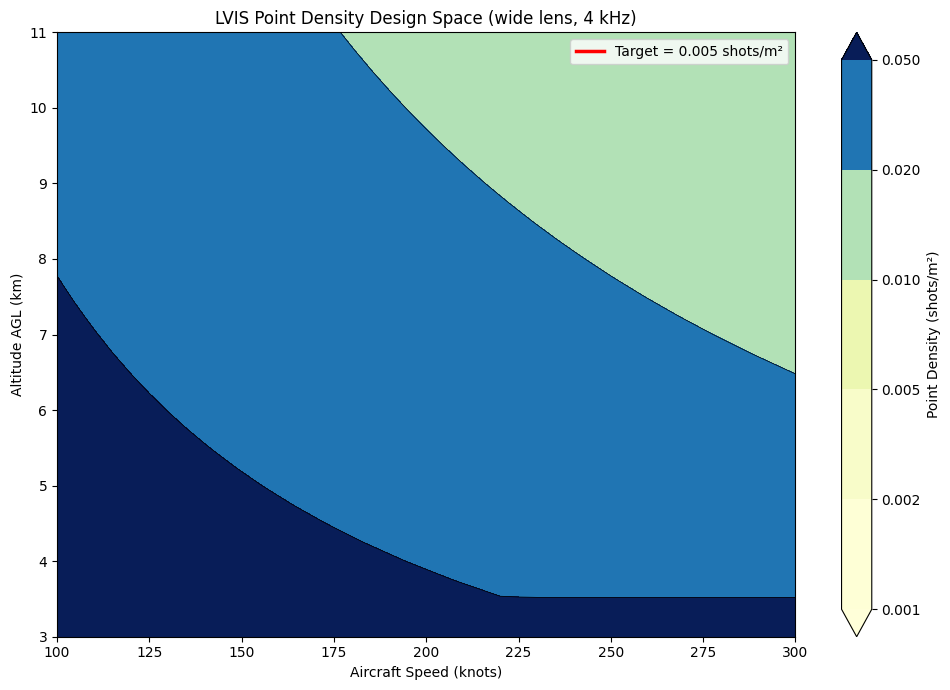

In [11]:
# Contour map: point density in altitude-speed space
lvis_w = LVIS(lens="wide")

alt_range = np.arange(3000, 11001, 250)
spd_range = np.arange(100, 301, 5)
ALT, SPD = np.meshgrid(alt_range, spd_range)

DENSITY = np.zeros_like(ALT, dtype=float)
for i in range(ALT.shape[0]):
    for j in range(ALT.shape[1]):
        DENSITY[i, j] = lvis_w.point_density(
            ureg.Quantity(ALT[i, j], "meter"),
            ureg.Quantity(SPD[i, j], "knot"),
        ).magnitude

fig, ax = plt.subplots(figsize=(10, 7))
levels = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
cs = ax.contourf(SPD, ALT / 1000, DENSITY, levels=levels, extend="both", cmap="YlGnBu")
cbar = fig.colorbar(cs, ax=ax, label="Point Density (shots/m²)")
ax.contour(SPD, ALT / 1000, DENSITY, levels=levels, colors="k", linewidths=0.5)

# Overlay solver constraint: target = 0.005
target = 0.005
solver_speeds = []
solver_alts = []
for a in alt_range:
    try:
        v = lvis_w.solve_for_speed(target / ureg.meter ** 2, a * ureg.meter)
        v_kt = v.to(ureg.knot).magnitude
        if 100 <= v_kt <= 300:
            solver_speeds.append(v_kt)
            solver_alts.append(a / 1000)
    except Exception:
        pass
ax.plot(solver_speeds, solver_alts, "r-", linewidth=2.5, label=f"Target = {target} shots/m²")

ax.set_xlabel("Aircraft Speed (knots)")
ax.set_ylabel("Altitude AGL (km)")
ax.set_title("LVIS Point Density Design Space (wide lens, 4 kHz)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 8. Swath Polygon Generation

LVIS implements the standard `Sensor` interface (`swath_width`, `half_angle`),
so it works directly with `generate_swath_polygon` and flight box generation.

/Users/rpavlick/.pyenv/versions/3.11.11/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


LVIS swath for LVIS Caribbean:
  Min width:  1536 m
  Mean width: 1645 m
  Max width:  1710 m
  Theoretical max: 1707 m


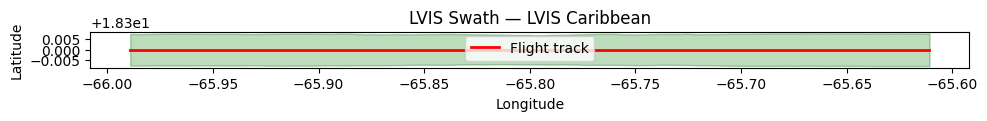

In [12]:
fl = FlightLine.center_length_azimuth(
    lat=18.3, lon=-65.8,
    length=ureg.Quantity(40, "km"),
    az=90.0,
    altitude_msl=ureg.Quantity(28000, "feet"),
    site_name="LVIS Caribbean",
)

lvis_sensor = LVIS(lens="wide")
swath = generate_swath_polygon(fl, lvis_sensor)
widths = calculate_swath_widths(swath)

print(f"LVIS swath for {fl.site_name}:")
print(f"  Min width:  {widths['min_width']:.0f} m")
print(f"  Mean width: {widths['mean_width']:.0f} m")
print(f"  Max width:  {widths['max_width']:.0f} m")

# Theoretical max swath
theoretical = lvis_sensor.swath_width(fl.altitude_msl).to(ureg.meter).magnitude
print(f"  Theoretical max: {theoretical:.0f} m")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
gpd.GeoSeries([swath]).plot(ax=ax, alpha=0.3, color="forestgreen", edgecolor="darkgreen")
x, y = fl.geometry.xy
ax.plot(x, y, "r-", linewidth=2, label="Flight track")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"LVIS Swath — {fl.site_name}")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 9. Altitude and Speed Trade-offs

LVIS mission planning involves balancing:
- **Higher altitude** = wider swath (fewer lines) but larger footprint needed for contiguous coverage
- **Slower speed** = easier to achieve contiguous coverage but less area covered per hour

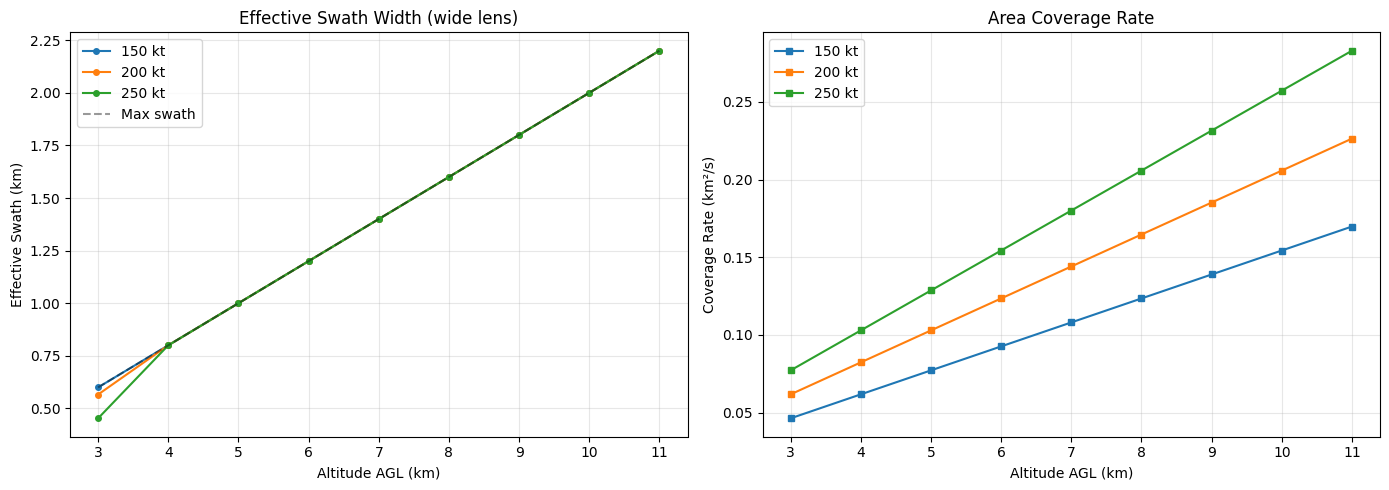

In [13]:
alts = np.arange(3000, 11001, 1000)
speeds = [150, 200, 250]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lvis_w = LVIS(lens="wide")

for spd in speeds:
    speed = ureg.Quantity(spd, "knot")
    eff = [lvis_w.effective_swath_width(ureg.Quantity(a, "meter"), speed).magnitude / 1000 for a in alts]
    mx = [lvis_w.swath_width(ureg.Quantity(a, "meter")).magnitude / 1000 for a in alts]
    cov = [lvis_w.coverage_rate(ureg.Quantity(a, "meter"), speed).magnitude / 1e6 for a in alts]

    axes[0].plot(alts / 1000, eff, "o-", markersize=4, label=f"{spd} kt")
    axes[1].plot(alts / 1000, cov, "s-", markersize=4, label=f"{spd} kt")

# Add max swath line
axes[0].plot(alts / 1000, mx, "k--", alpha=0.4, label="Max swath")

axes[0].set_xlabel("Altitude AGL (km)")
axes[0].set_ylabel("Effective Swath (km)")
axes[0].set_title("Effective Swath Width (wide lens)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Altitude AGL (km)")
axes[1].set_ylabel("Coverage Rate (km²/s)")
axes[1].set_title("Area Coverage Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Custom Repetition Rate

LVIS can operate at different repetition rates. Higher rep rates
improve contiguous coverage at higher speeds.

In [14]:
altitude = ureg.Quantity(8000, "meter")
speed = ureg.Quantity(250, "knot")

rep_rates = [2000, 4000, 8000, 10000]

rows = []
for rr in rep_rates:
    lvis_rr = LVIS(rep_rate=rr * ureg.Hz, lens="wide")
    s = lvis_rr.summary(altitude, speed)
    rows.append({
        "Rep Rate (Hz)": rr,
        "Footprint (m)": f"{s['footprint_diameter'].magnitude:.1f}",
        "Max Swath (m)": f"{s['max_swath'].magnitude:.0f}",
        "Eff Swath (m)": f"{s['effective_swath_width'].magnitude:.0f}",
        "Contiguous": s['contiguous'],
    })

rr_df = pd.DataFrame(rows)
print(f"LVIS coverage at {altitude.to(ureg.km):.0f} AGL, {speed} (wide lens):\n")
rr_df

LVIS coverage at 8 kilometer AGL, 250 knot (wide lens):



,Rep Rate (Hz),Footprint (m),Max Swath (m),Eff Swath (m),Contiguous
0,2000,10.2,1600,1600,True
1,4000,10.2,1600,1600,True
2,8000,10.2,1600,1600,True
3,10000,10.2,1600,1600,True


## 11. Terrain-Aware Footprint Analysis

On flat ground the laser footprint is a circle. On sloped terrain the beam
hits at an oblique incidence angle, stretching the footprint into an ellipse
and increasing the slant range. This affects contiguity and point density —
especially on mountainous terrain where slopes can cause 15-30% footprint
variation across the swath.

The terrain-aware methods require a DEM (auto-downloaded from Copernicus GLO-30
if not provided).

**Note:** The cells below require network access to download DEM tiles.
They will fail if run offline.

In [15]:
# Define a flight line over Denali National Park, AK
# Terrain ranges from ~600m (valleys) to ~4500m+ (Denali approaches)
from hyplan.terrain import generate_demfile, get_elevations
from hyplan.geometry import process_linestring

fl_terrain = FlightLine.center_length_azimuth(
    lat=63.10, lon=-151.00,
    length=ureg.Quantity(40, "km"),
    az=180.0,  # north-south line across the range
    altitude_msl=ureg.Quantity(12000, "meter"),
    site_name="Denali National Park",
)

# Pre-download DEM for the area
dem_file = generate_demfile(63.10, -151.00)

# Sample along-track positions
lats_track, lons_track, headings_track, *_ = process_linestring(
    fl_terrain.track(precision=500.0)  # every 500m
)
n_along = len(lats_track)
print(f"Flight line: {fl_terrain.site_name}")
print(f"  {n_along} along-track positions sampled every 500 m")
print(f"  Aircraft altitude: {fl_terrain.altitude_msl.to(ureg.meter):.0f}")

# Preview terrain relief
terrain_elev = get_elevations(lats_track, lons_track, dem_file)
print(f"  Terrain range: {terrain_elev.min():.0f} \u2013 {terrain_elev.max():.0f} m MSL")
print(f"  AGL range: {12000 - terrain_elev.max():.0f} \u2013 {12000 - terrain_elev.min():.0f} m")


Flight line: Denali National Park
  81 along-track positions sampled every 500 m
  Aircraft altitude: 12000 meter
  Terrain range: 856 – 6120 m MSL
  AGL range: 5880 – 11144 m


In [16]:
# Compute effective_swath_on_terrain at each along-track position
# This builds 2D arrays: (along-track position) x (scan angle)

lvis_t = LVIS(lens="wide")
altitude_msl = fl_terrain.altitude_msl.m_as(ureg.meter)
n_scan = 21

# Collect 2D grids
all_fp = np.full((n_along, n_scan), np.nan)
all_inc = np.full((n_along, n_scan), np.nan)
all_sr = np.full((n_along, n_scan), np.nan)
all_density = np.full((n_along, n_scan), np.nan)
all_cont = np.full((n_along, n_scan), False)
all_cont_cross = np.full((n_along, n_scan), False)
all_cont_along = np.full((n_along, n_scan), False)
scan_angles = None

for i in range(n_along):
    result = lvis_t.effective_swath_on_terrain(
        lat=lats_track[i], lon=lons_track[i],
        altitude_msl=altitude_msl,
        heading=headings_track[i],
        speed=200 * ureg.knot,
        dem_file=dem_file,
        n_scan_positions=n_scan,
    )
    if scan_angles is None:
        scan_angles = result["scan_angles_deg"]
    all_fp[i, :] = result["footprint_diameters_m"]
    all_inc[i, :] = result["incidence_angles_deg"]
    all_sr[i, :] = result["slant_ranges_m"]
    all_density[i, :] = result["local_densities"]
    all_cont[i, :] = result["contiguous_mask"]
    all_cont_cross[i, :] = result["contiguous_cross_track"]
    all_cont_along[i, :] = result["contiguous_along_track"]

# Along-track distance in km
along_dist = np.arange(n_along) * 0.5  # 500m spacing

# Density summary across the entire grid
valid_d = np.isfinite(all_density)
if valid_d.any():
    print(f"Computed {n_along} x {n_scan} = {n_along * n_scan} terrain footprints")
    print(f"  Point density range: {all_density[valid_d].min():.4f} – {all_density[valid_d].max():.4f} shots/m²")
    print(f"  Mean density: {all_density[valid_d].mean():.4f} shots/m²")
    print(f"  Fully contiguous: {all_cont.all()}, cross-track: {all_cont_cross.all()}, along-track: {all_cont_along.all()}")


Computed 81 x 21 = 1701 terrain footprints


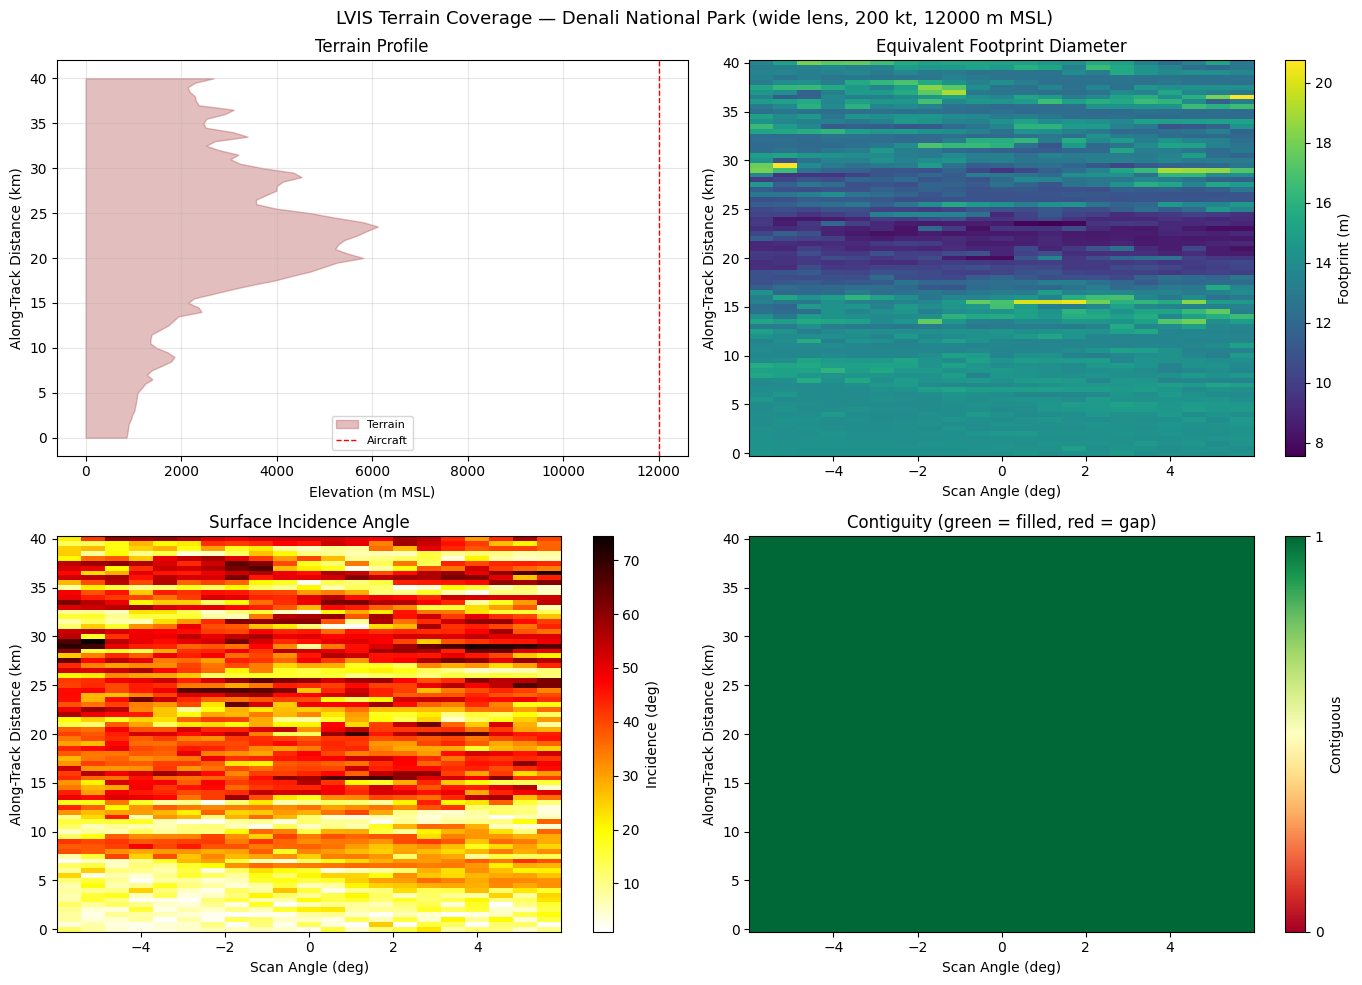

In [17]:
# 2D maps: terrain-aware coverage analysis
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Terrain profile
terrain_elev = get_elevations(lats_track, lons_track, dem_file)
axes[0, 0].fill_between(along_dist, 0, terrain_elev, alpha=0.3, color="brown", label="Terrain")
axes[0, 0].axhline(altitude_msl, color="r", linestyle="--", linewidth=1, label="Aircraft")
axes[0, 0].set_xlabel("Along-Track Distance (km)")
axes[0, 0].set_ylabel("Elevation (m MSL)")
axes[0, 0].set_title("Terrain Profile")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

ALONG, SCAN = np.meshgrid(along_dist, scan_angles, indexing="ij")

# Footprint diameter
im1 = axes[0, 1].pcolormesh(ALONG, SCAN, all_fp, cmap="viridis", shading="auto")
fig.colorbar(im1, ax=axes[0, 1], label="Footprint (m)")
axes[0, 1].set_xlabel("Along-Track Distance (km)")
axes[0, 1].set_ylabel("Scan Angle (deg)")
axes[0, 1].set_title("Equivalent Footprint Diameter")

# Incidence angle
im2 = axes[1, 0].pcolormesh(ALONG, SCAN, all_inc, cmap="hot_r", shading="auto")
fig.colorbar(im2, ax=axes[1, 0], label="Incidence (deg)")
axes[1, 0].set_xlabel("Along-Track Distance (km)")
axes[1, 0].set_ylabel("Scan Angle (deg)")
axes[1, 0].set_title("Surface Incidence Angle")

# Local point density
im3 = axes[1, 1].pcolormesh(ALONG, SCAN, all_density, cmap="YlGnBu", shading="auto")
fig.colorbar(im3, ax=axes[1, 1], label="Density (shots/m\u00b2)")
axes[1, 1].set_xlabel("Along-Track Distance (km)")
axes[1, 1].set_ylabel("Scan Angle (deg)")
axes[1, 1].set_title("Local Point Density")

# Cross-track contiguity
im4 = axes[2, 0].pcolormesh(ALONG, SCAN, all_cont_cross.astype(float),
                             cmap="RdYlGn", vmin=0, vmax=1, shading="auto")
fig.colorbar(im4, ax=axes[2, 0], label="Contiguous", ticks=[0, 1])
axes[2, 0].set_xlabel("Along-Track Distance (km)")
axes[2, 0].set_ylabel("Scan Angle (deg)")
axes[2, 0].set_title("Cross-Track Contiguity")

# Combined contiguity (cross + along)
im5 = axes[2, 1].pcolormesh(ALONG, SCAN, all_cont.astype(float),
                             cmap="RdYlGn", vmin=0, vmax=1, shading="auto")
fig.colorbar(im5, ax=axes[2, 1], label="Contiguous", ticks=[0, 1])
axes[2, 1].set_xlabel("Along-Track Distance (km)")
axes[2, 1].set_ylabel("Scan Angle (deg)")
axes[2, 1].set_title("Combined Contiguity (cross + along)")

fig.suptitle(
    f"LVIS Terrain Coverage \u2014 {fl_terrain.site_name} "
    f"(wide lens, 200 kt, {altitude_msl:.0f} m MSL)",
    fontsize=13,
)
plt.tight_layout()
plt.show()


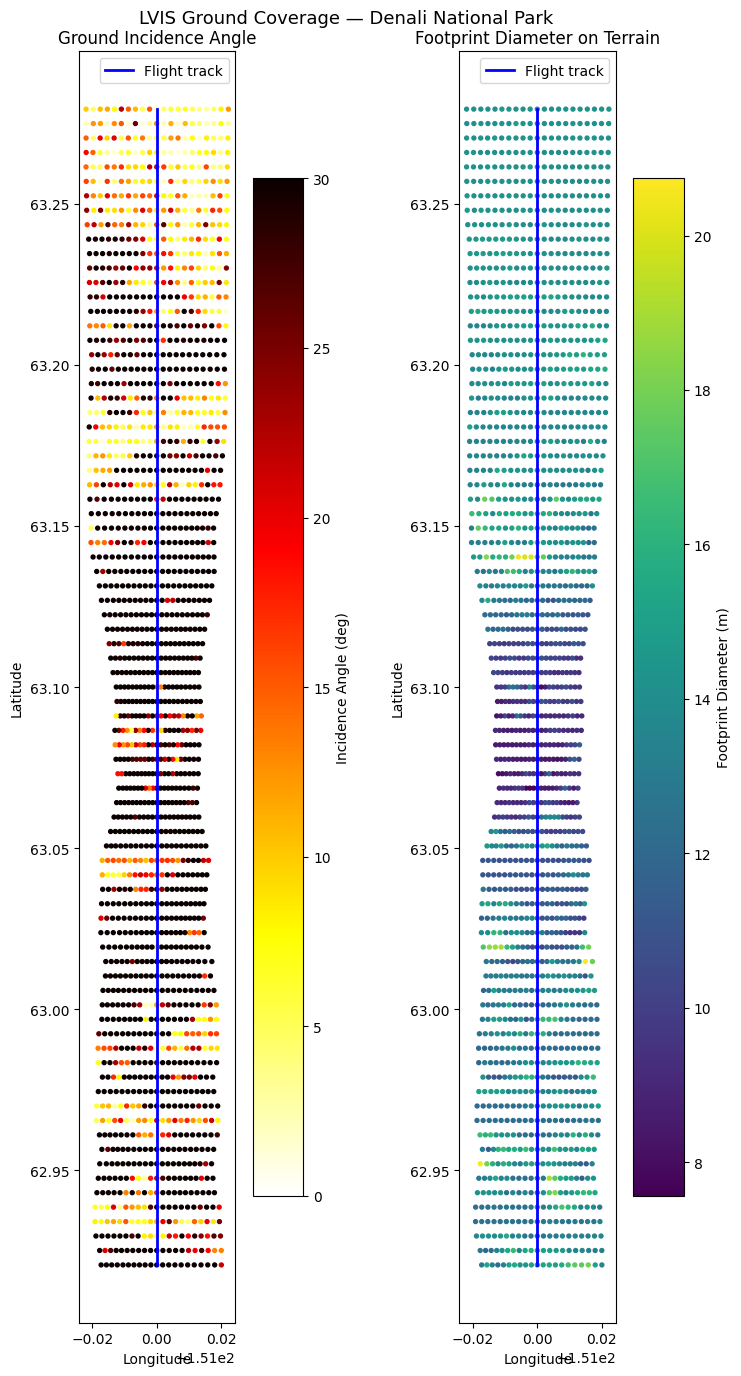

In [19]:
# Geographic maps: incidence, density, and terrain elevation

all_gnd_lats = np.full((n_along, n_scan), np.nan)
all_gnd_lons = np.full((n_along, n_scan), np.nan)
all_gnd_alts = np.full((n_along, n_scan), np.nan)

for i in range(n_along):
    result = lvis_t.effective_swath_on_terrain(
        lat=lats_track[i], lon=lons_track[i],
        altitude_msl=altitude_msl,
        heading=headings_track[i],
        speed=200 * ureg.knot,
        dem_file=dem_file,
        n_scan_positions=n_scan,
    )
    all_gnd_lats[i, :] = result["ground_lats"]
    all_gnd_lons[i, :] = result["ground_lons"]
    # Get ground elevation at each scan position
    gnd_valid = np.isfinite(result["ground_lats"])
    if gnd_valid.any():
        all_gnd_alts[i, gnd_valid] = get_elevations(
            result["ground_lats"][gnd_valid],
            result["ground_lons"][gnd_valid],
            dem_file,
        )

fig, axes = plt.subplots(3, 1, figsize=(8, 18))

valid = np.isfinite(all_gnd_lats)

# Top: incidence angle
valid_inc = valid & np.isfinite(all_inc)
sc1 = axes[0].scatter(
    all_gnd_lons[valid_inc], all_gnd_lats[valid_inc],
    c=all_inc[valid_inc], cmap="hot_r", s=8, vmin=0, vmax=30,
)
axes[0].plot(lons_track, lats_track, "b-", linewidth=2, label="Flight track")
fig.colorbar(sc1, ax=axes[0], label="Incidence Angle (deg)", shrink=0.8)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Ground Incidence Angle")
axes[0].legend()
axes[0].set_aspect("equal")

# Middle: local point density
valid_d = valid & np.isfinite(all_density)
sc2 = axes[1].scatter(
    all_gnd_lons[valid_d], all_gnd_lats[valid_d],
    c=all_density[valid_d], cmap="YlGnBu", s=8,
)
axes[1].plot(lons_track, lats_track, "b-", linewidth=2, label="Flight track")
fig.colorbar(sc2, ax=axes[1], label="Point Density (shots/m\u00b2)", shrink=0.8)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Local Point Density on Terrain")
axes[1].legend()
axes[1].set_aspect("equal")

# Bottom: terrain elevation
valid_alt = valid & np.isfinite(all_gnd_alts)
sc3 = axes[2].scatter(
    all_gnd_lons[valid_alt], all_gnd_lats[valid_alt],
    c=all_gnd_alts[valid_alt], cmap="terrain", s=8,
)
axes[2].plot(lons_track, lats_track, "b-", linewidth=2, label="Flight track")
fig.colorbar(sc3, ax=axes[2], label="Elevation (m MSL)", shrink=0.8)
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
axes[2].set_title("Terrain Elevation at Ground Points")
axes[2].legend()
axes[2].set_aspect("equal")

fig.suptitle(f"LVIS Ground Coverage \u2014 {fl_terrain.site_name}", fontsize=13)
plt.tight_layout()
plt.show()


## API Summary

| Feature | Method | Purpose |
|---------|--------|---------|
| **Configuration** | `LVIS(rep_rate, lens, scan_half_angle_deg)` | Configure laser scanner |
| Lens options | `LVIS_LENS_NARROW / MEDIUM / WIDE` | Control footprint size |
| **Flat-earth geometry** | | |
| Max swath | `swath_width(altitude)` | Geometric scanner limit |
| Effective swath | `effective_swath_width(altitude, speed)` | Contiguous-coverage limit |
| Cross-track contiguity | `is_contiguous(altitude, speed)` | Full swath filled? |
| Along-track spacing | `along_track_spacing(speed)` | Shot spacing along flight track |
| Along-track contiguity | `is_along_track_contiguous(altitude, speed)` | Shots overlap along-track? |
| **Point density** | `point_density(altitude, speed)` | Shots per m^2 — primary planning metric |
| **Survey solvers** | | |
| Max speed | `solve_for_speed(density, altitude)` | Fastest speed meeting density target |
| Max altitude | `solve_for_altitude(density, speed)` | Highest altitude meeting density target |
| **Terrain-aware** | | |
| Footprint on terrain | `footprint_on_terrain(lat, lon, alt_msl, heading, ...)` | Slant range, incidence, ellipse |
| Cross-track on terrain | `effective_swath_on_terrain(lat, lon, alt_msl, heading, speed, ...)` | Per-position contiguity and density |
| Terrain summary | `terrain_summary(lat, lon, alt_msl, heading, speed, ...)` | Combined flat + terrain metrics |
| **Diagnostics** | | |
| Equivalent FOV | `equivalent_fov(altitude, speed)` | FOV accounting for coverage limits |
| Coverage rate | `coverage_rate(altitude, speed)` | Area per unit time |
| Summary / compare | `print_summary()`, `compare_lenses()` | Quick formatted output |